# Telco Customer Churn - Predspracovanie a vyber atributov

Tento notebook pokryva:
- nacitanie dat s ciselnycmi aj kategorickymi atributmi
- osetrenie chybajucich hodnot (`TotalCharges` + imputacia v pipeline)
- pripravu train/test splitu
- vyber relevantnych atributov pomocou `mutual_info_classif`
- export pripravnych suborov pre modelovanie


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif

RANDOM_STATE = 42
TEST_SIZE = 0.2

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Projekt:", PROJECT_ROOT)
print("Raw data:", RAW_DATA_PATH)


Projekt: C:\Users\kuboj\Desktop\INSA zadanie
Raw data: C:\Users\kuboj\Desktop\INSA zadanie\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df = raw_df.copy()

# V datasete su prazdne retazce v stlpci TotalCharges, premenime ich na NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")

# Binarny target prevedieme na 0/1.
df["Churn"] = df["Churn"].str.strip().map({"No": 0, "Yes": 1})

display(df.info())
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

None

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
missing_table = df.isna().sum().to_frame("missing_count")
missing_table["missing_pct"] = (missing_table["missing_count"] / len(df) * 100).round(2)
missing_table[missing_table["missing_count"] > 0].sort_values("missing_count", ascending=False)


,missing_count,missing_pct
TotalCharges,11,0.16


In [6]:
class_distribution = df["Churn"].value_counts(normalize=True).mul(100).round(2)
print("Podiel tried (%):")
print(class_distribution)


Podiel tried (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [7]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Train shape: (5634, 19)
Test shape: (1409, 19)
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:
selector_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_features
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_sel = selector_preprocessor.fit_transform(X_train)
feature_names = selector_preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(X_train_sel, y_train, random_state=RANDOM_STATE)
mi_df = (
    pd.DataFrame({"feature": feature_names, "mutual_info": mi_scores})
    .sort_values("mutual_info", ascending=False)
    .reset_index(drop=True)
)

mi_df.head(20)


,feature,mutual_info
0,Contract_Month-to-month,0.088273
1,tenure,0.076660
2,Contract_Two year,0.062771
3,TechSupport_No,0.061098
4,OnlineSecurity_No,0.054088
5,InternetService_Fiber optic,0.053658
6,MonthlyCharges,0.051786
7,PaymentMethod_Electronic check,0.043265
8,InternetService_No,0.040834
9,TotalCharges,0.039574


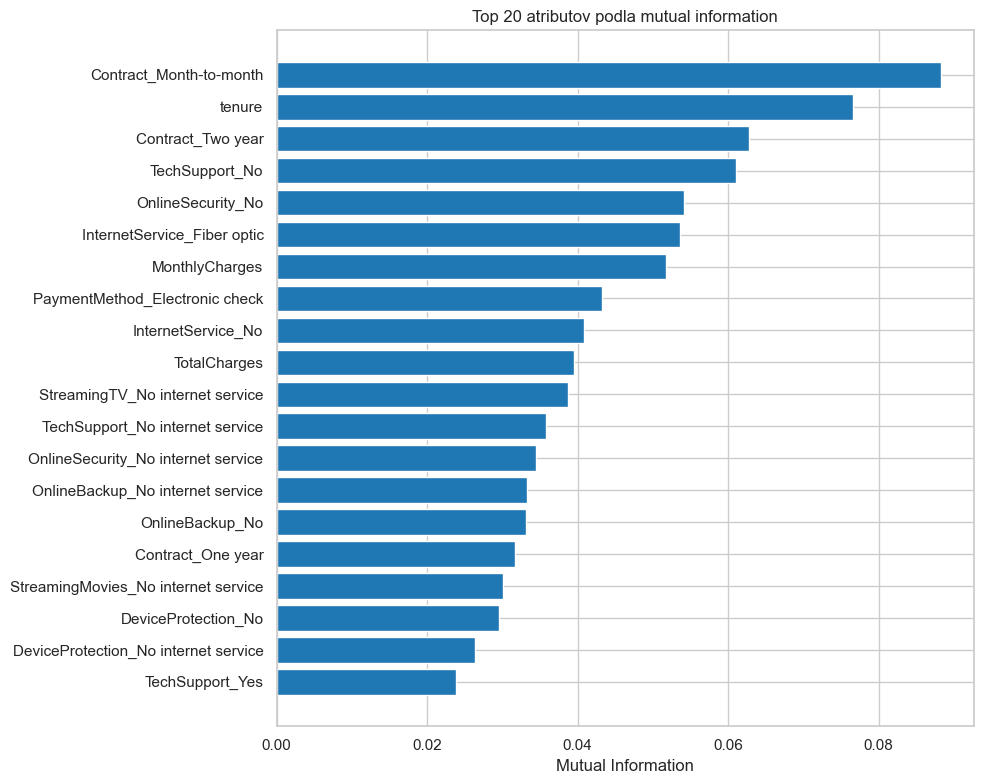

In [9]:
top_n = 20
top_features = mi_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["mutual_info"], color="#1f77b4")
plt.title(f"Top {top_n} atributov podla mutual information")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()


In [10]:
K_BEST = min(30, len(mi_df))
selected_features = mi_df.head(K_BEST)["feature"].tolist()

train_df = X_train.copy()
train_df["Churn"] = y_train.values

test_df = X_test.copy()
test_df["Churn"] = y_test.values

cleaned_path = PROCESSED_DIR / "cleaned_telco.csv"
train_path = PROCESSED_DIR / "train.csv"
test_path = PROCESSED_DIR / "test.csv"
feature_scores_path = PROCESSED_DIR / "feature_scores_mutual_info.csv"
metadata_path = PROCESSED_DIR / "metadata.json"

df.to_csv(cleaned_path, index=False)
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)
mi_df.to_csv(feature_scores_path, index=False)

metadata = {
    "dataset": "Telco Customer Churn",
    "target_column": "Churn",
    "target_mapping": {"No": 0, "Yes": 1},
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "k_best_default": K_BEST,
    "top_selected_features": selected_features,
    "n_rows_total": int(df.shape[0]),
    "n_rows_train": int(train_df.shape[0]),
    "n_rows_test": int(test_df.shape[0]),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Ulozene subory:")
print("-", cleaned_path)
print("-", train_path)
print("-", test_path)
print("-", feature_scores_path)
print("-", metadata_path)


Ulozene subory:
- C:\Users\kuboj\Desktop\INSA zadanie\data\processed\cleaned_telco.csv
- C:\Users\kuboj\Desktop\INSA zadanie\data\processed\train.csv
- C:\Users\kuboj\Desktop\INSA zadanie\data\processed\test.csv
- C:\Users\kuboj\Desktop\INSA zadanie\data\processed\feature_scores_mutual_info.csv
- C:\Users\kuboj\Desktop\INSA zadanie\data\processed\metadata.json
